In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.append(os.path.abspath(".."))   # repo 루트 추가
df = pd.read_excel("../data/raw/STMECH_AUS_SS.xls", sheet_name="alldata", header=5)
df = df.replace(["Na", "NA", "na", ""], np.nan)

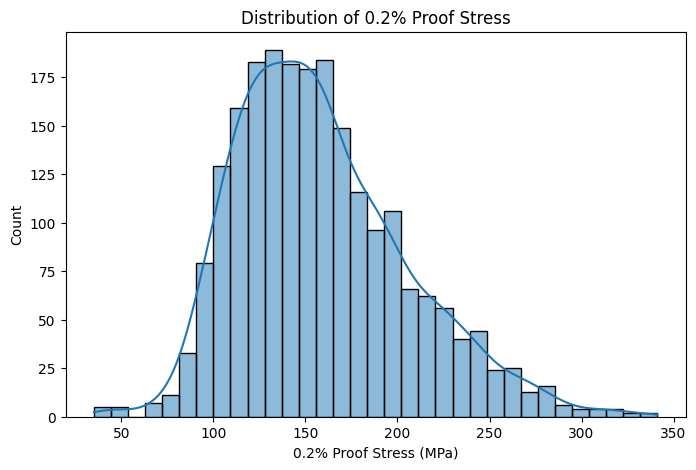

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(df["0.2%proof_stress (M Pa)"].dropna(), kde=True)
plt.title("Distribution of 0.2% Proof Stress")
plt.xlabel("0.2% Proof Stress (MPa)")
plt.ylabel("Count")
plt.show()

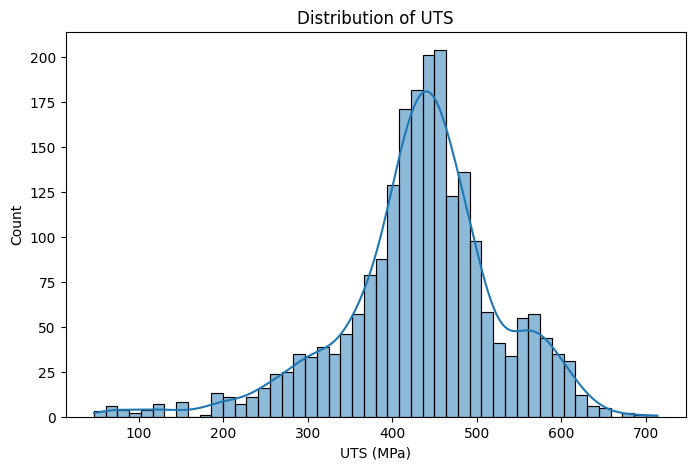

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(df["UTS (M Pa)"].dropna(), kde=True)
plt.title("Distribution of UTS")
plt.xlabel("UTS (MPa)")
plt.ylabel("Count")
plt.show()

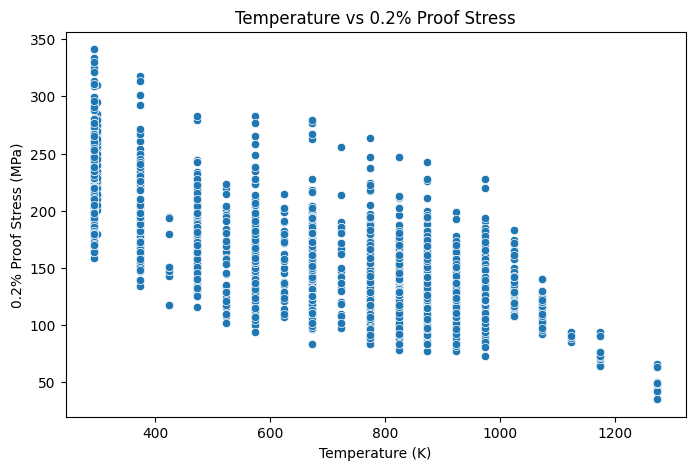

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Temperature (K)"], y=df["0.2%proof_stress (M Pa)"])
plt.title("Temperature vs 0.2% Proof Stress")
plt.xlabel("Temperature (K)")
plt.ylabel("0.2% Proof Stress (MPa)")
plt.show()

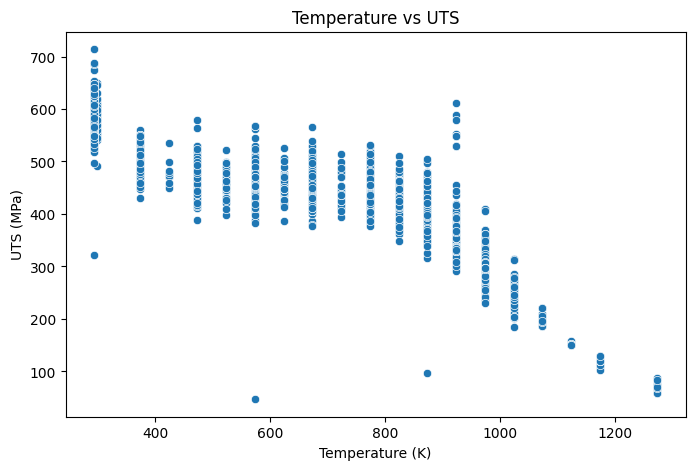

In [24]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Temperature (K)"], y=df["UTS (M Pa)"])
plt.title("Temperature vs UTS")
plt.xlabel("Temperature (K)")
plt.ylabel("UTS (MPa)")
plt.show()

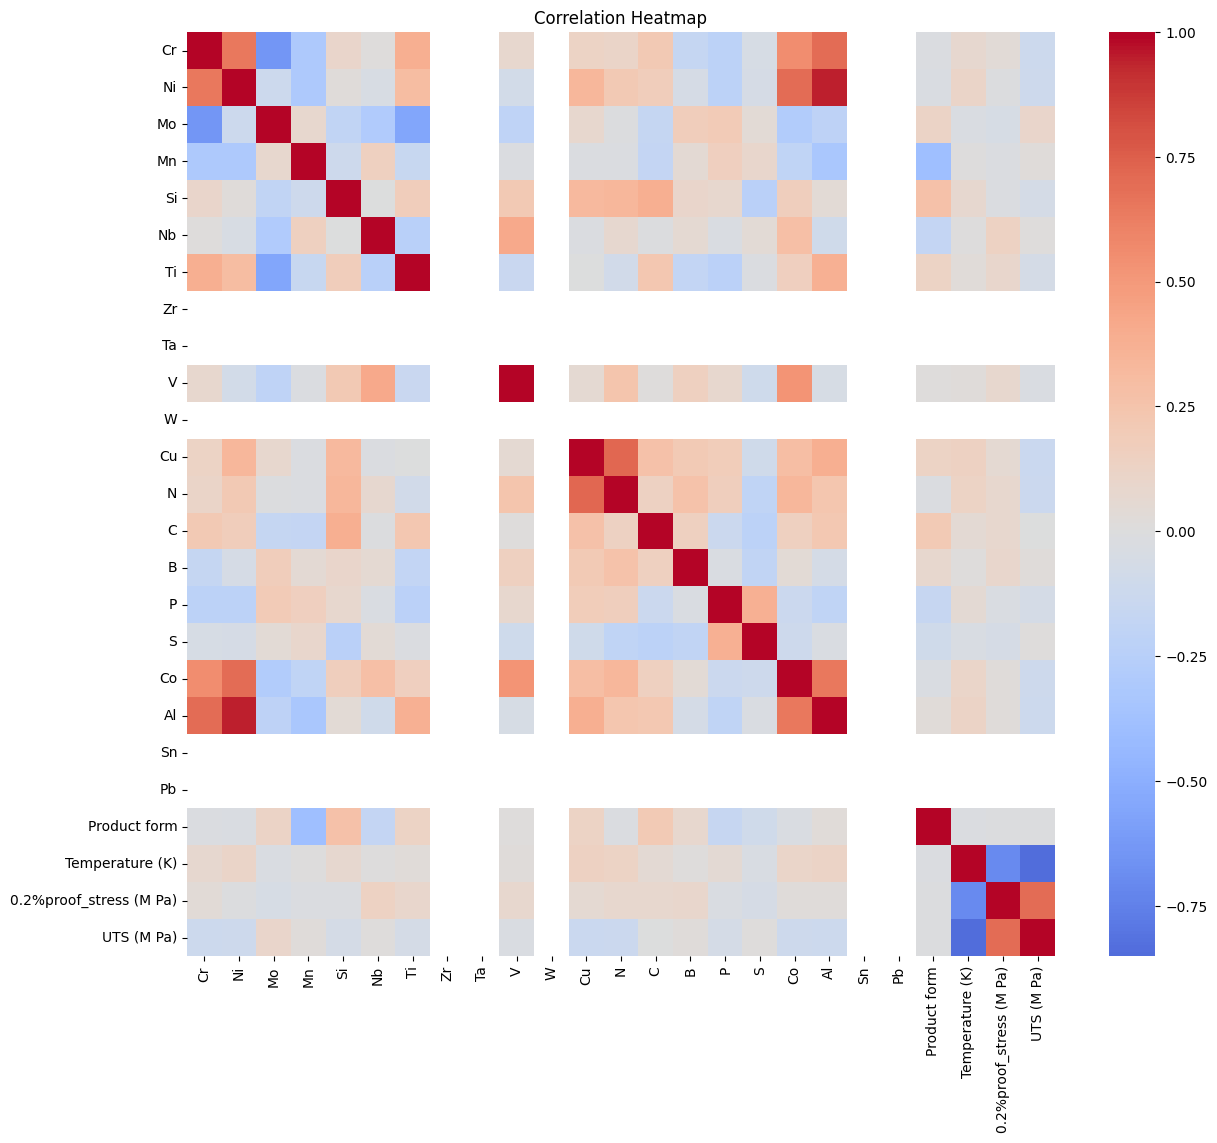

In [25]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [26]:
corr["0.2%proof_stress (M Pa)"].drop("0.2%proof_stress (M Pa)").sort_values(
    key=lambda s: s.abs(), ascending=False
).head(15)

Temperature (K)   -0.703747
UTS (M Pa)         0.699047
Nb                 0.136307
Ti                 0.096076
B                  0.089629
N                  0.085284
V                  0.083759
C                  0.078465
Cu                 0.060125
S                 -0.055841
Mo                -0.054119
Cr                 0.037349
P                 -0.030153
Co                 0.023869
Mn                -0.018709
Name: 0.2%proof_stress (M Pa), dtype: float64

In [27]:
corr["UTS (M Pa)"].drop("UTS (M Pa)").sort_values(
    key=lambda s: s.abs(), ascending=False
).head(15)

Temperature (K)           -0.850608
0.2%proof_stress (M Pa)    0.699047
Cu                        -0.139817
N                         -0.134484
Al                        -0.119939
Cr                        -0.116898
Co                        -0.110015
Ni                        -0.106818
Mo                         0.100830
Ti                        -0.069301
Si                        -0.067791
P                         -0.066114
V                         -0.033205
B                          0.018049
Mn                         0.017931
Name: UTS (M Pa), dtype: float64

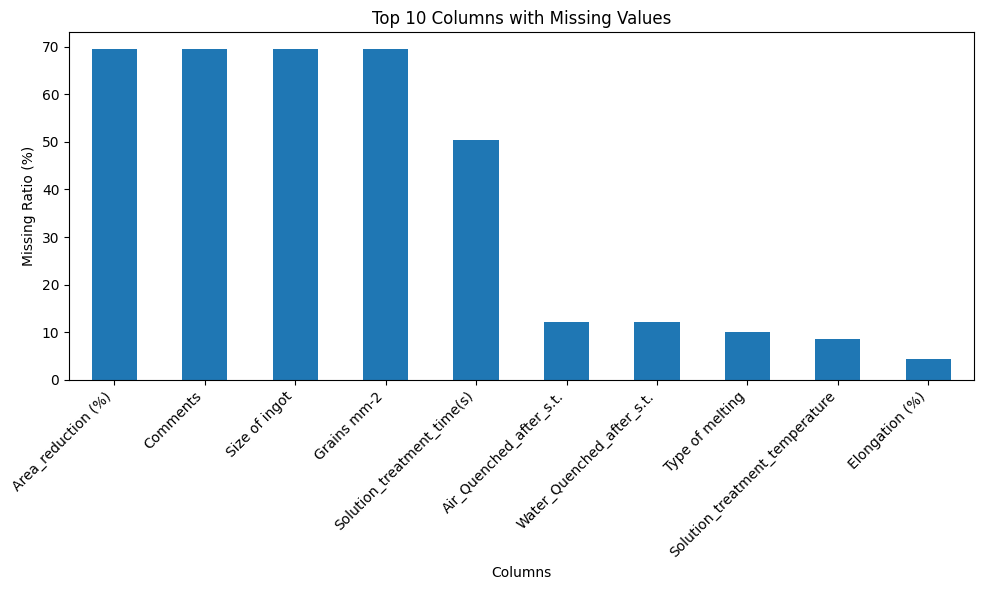

In [28]:
#결측치 시각화
missing_ratio = (df.isna().mean() * 100).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
missing_ratio.plot(kind="bar")
plt.title("Top 10 Columns with Missing Values")
plt.ylabel("Missing Ratio (%)")
plt.xlabel("Columns")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [29]:
#모델 성능 비교 그래프
proof_results = pd.read_csv("../outputs/reports/proof_stress_model_results.csv")
uts_results = pd.read_csv("../outputs/reports/uts_model_results.csv")

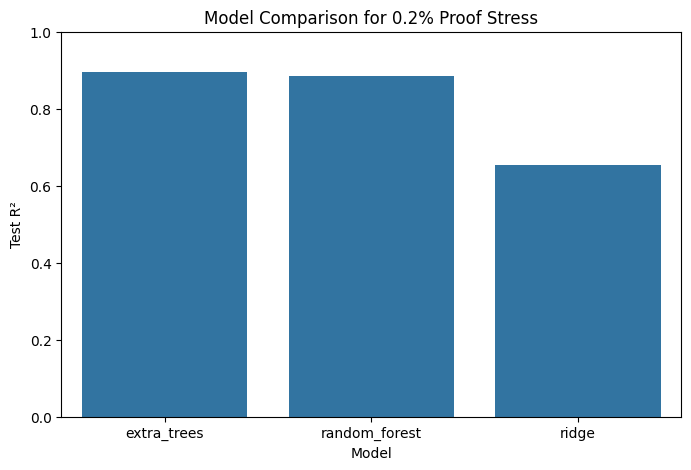

In [30]:
#proof stress 모델 R^2 비교
plt.figure(figsize=(8, 5))
sns.barplot(data=proof_results, x="model", y="test_r2")
plt.title("Model Comparison for 0.2% Proof Stress")
plt.ylabel("Test R²")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.show()

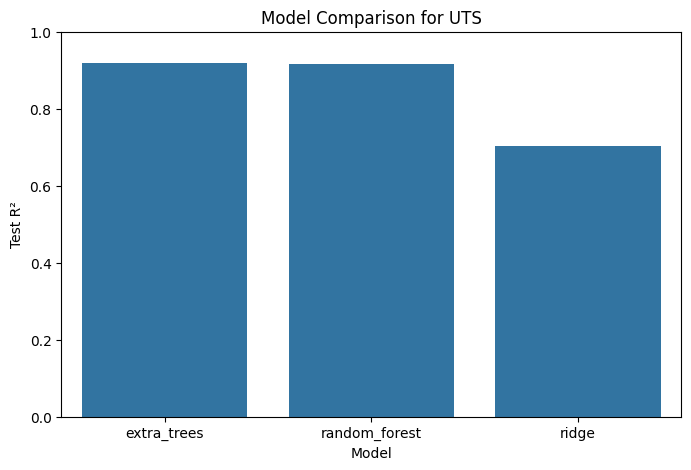

In [31]:
#UTS 모델 R^2 비교
plt.figure(figsize=(8, 5))
sns.barplot(data=uts_results, x="model", y="test_r2")
plt.title("Model Comparison for UTS")
plt.ylabel("Test R²")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.show()

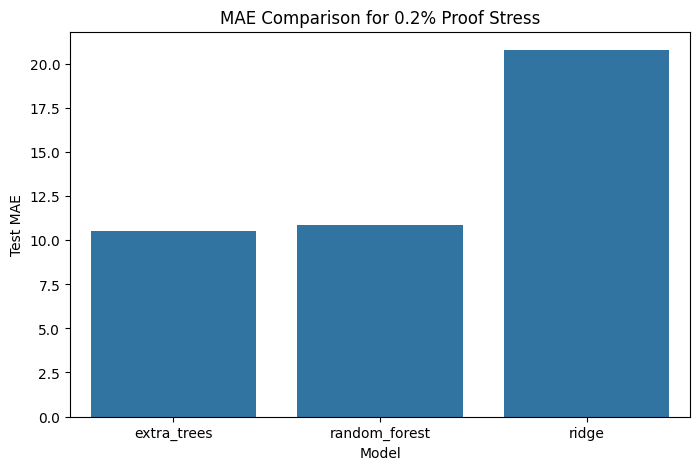

In [32]:
#MAE 비교
plt.figure(figsize=(8, 5))
sns.barplot(data=proof_results, x="model", y="test_mae")
plt.title("MAE Comparison for 0.2% Proof Stress")
plt.ylabel("Test MAE")
plt.xlabel("Model")
plt.show()

In [33]:
#변수 중요도 그래프
proof_importance = pd.read_csv("../outputs/reports/proof_stress_feature_importance.csv")
uts_importance = pd.read_csv("../outputs/reports/uts_feature_importance.csv")

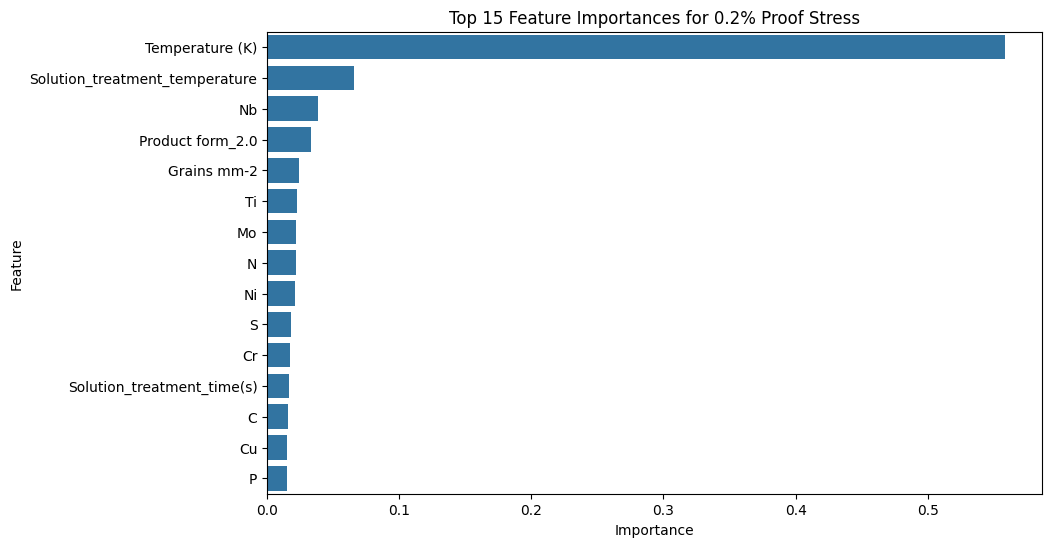

In [34]:
#proof stress 중요도 상위 15개
top15 = proof_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top15, x="importance", y="feature")
plt.title("Top 15 Feature Importances for 0.2% Proof Stress")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

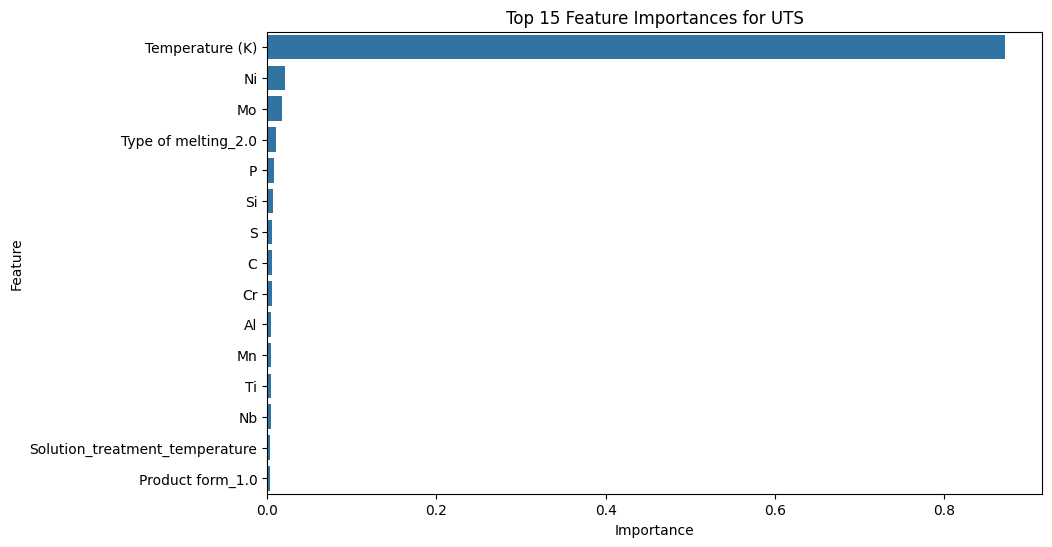

In [35]:
#UTS 중요도 상위 15개
top15 = uts_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top15, x="importance", y="feature")
plt.title("Top 15 Feature Importances for UTS")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

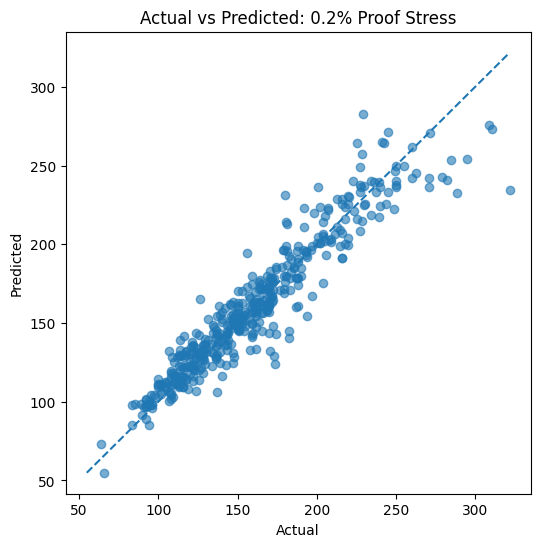

In [36]:
#실제값 vs 예측값 그래프
from src.config import RAW_DATA_PATH
from src.data_loader import load_data
from src.preprocess import get_feature_columns, make_preprocessor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor
import matplotlib.pyplot as plt

df = load_data(RAW_DATA_PATH)
feature_cols, numeric_cols, categorical_cols = get_feature_columns(df)

X = df[feature_cols]
y = df["0.2%proof_stress (M Pa)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ("preprocess", make_preprocessor(numeric_cols, categorical_cols)),
    ("model", ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted: 0.2% Proof Stress")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()


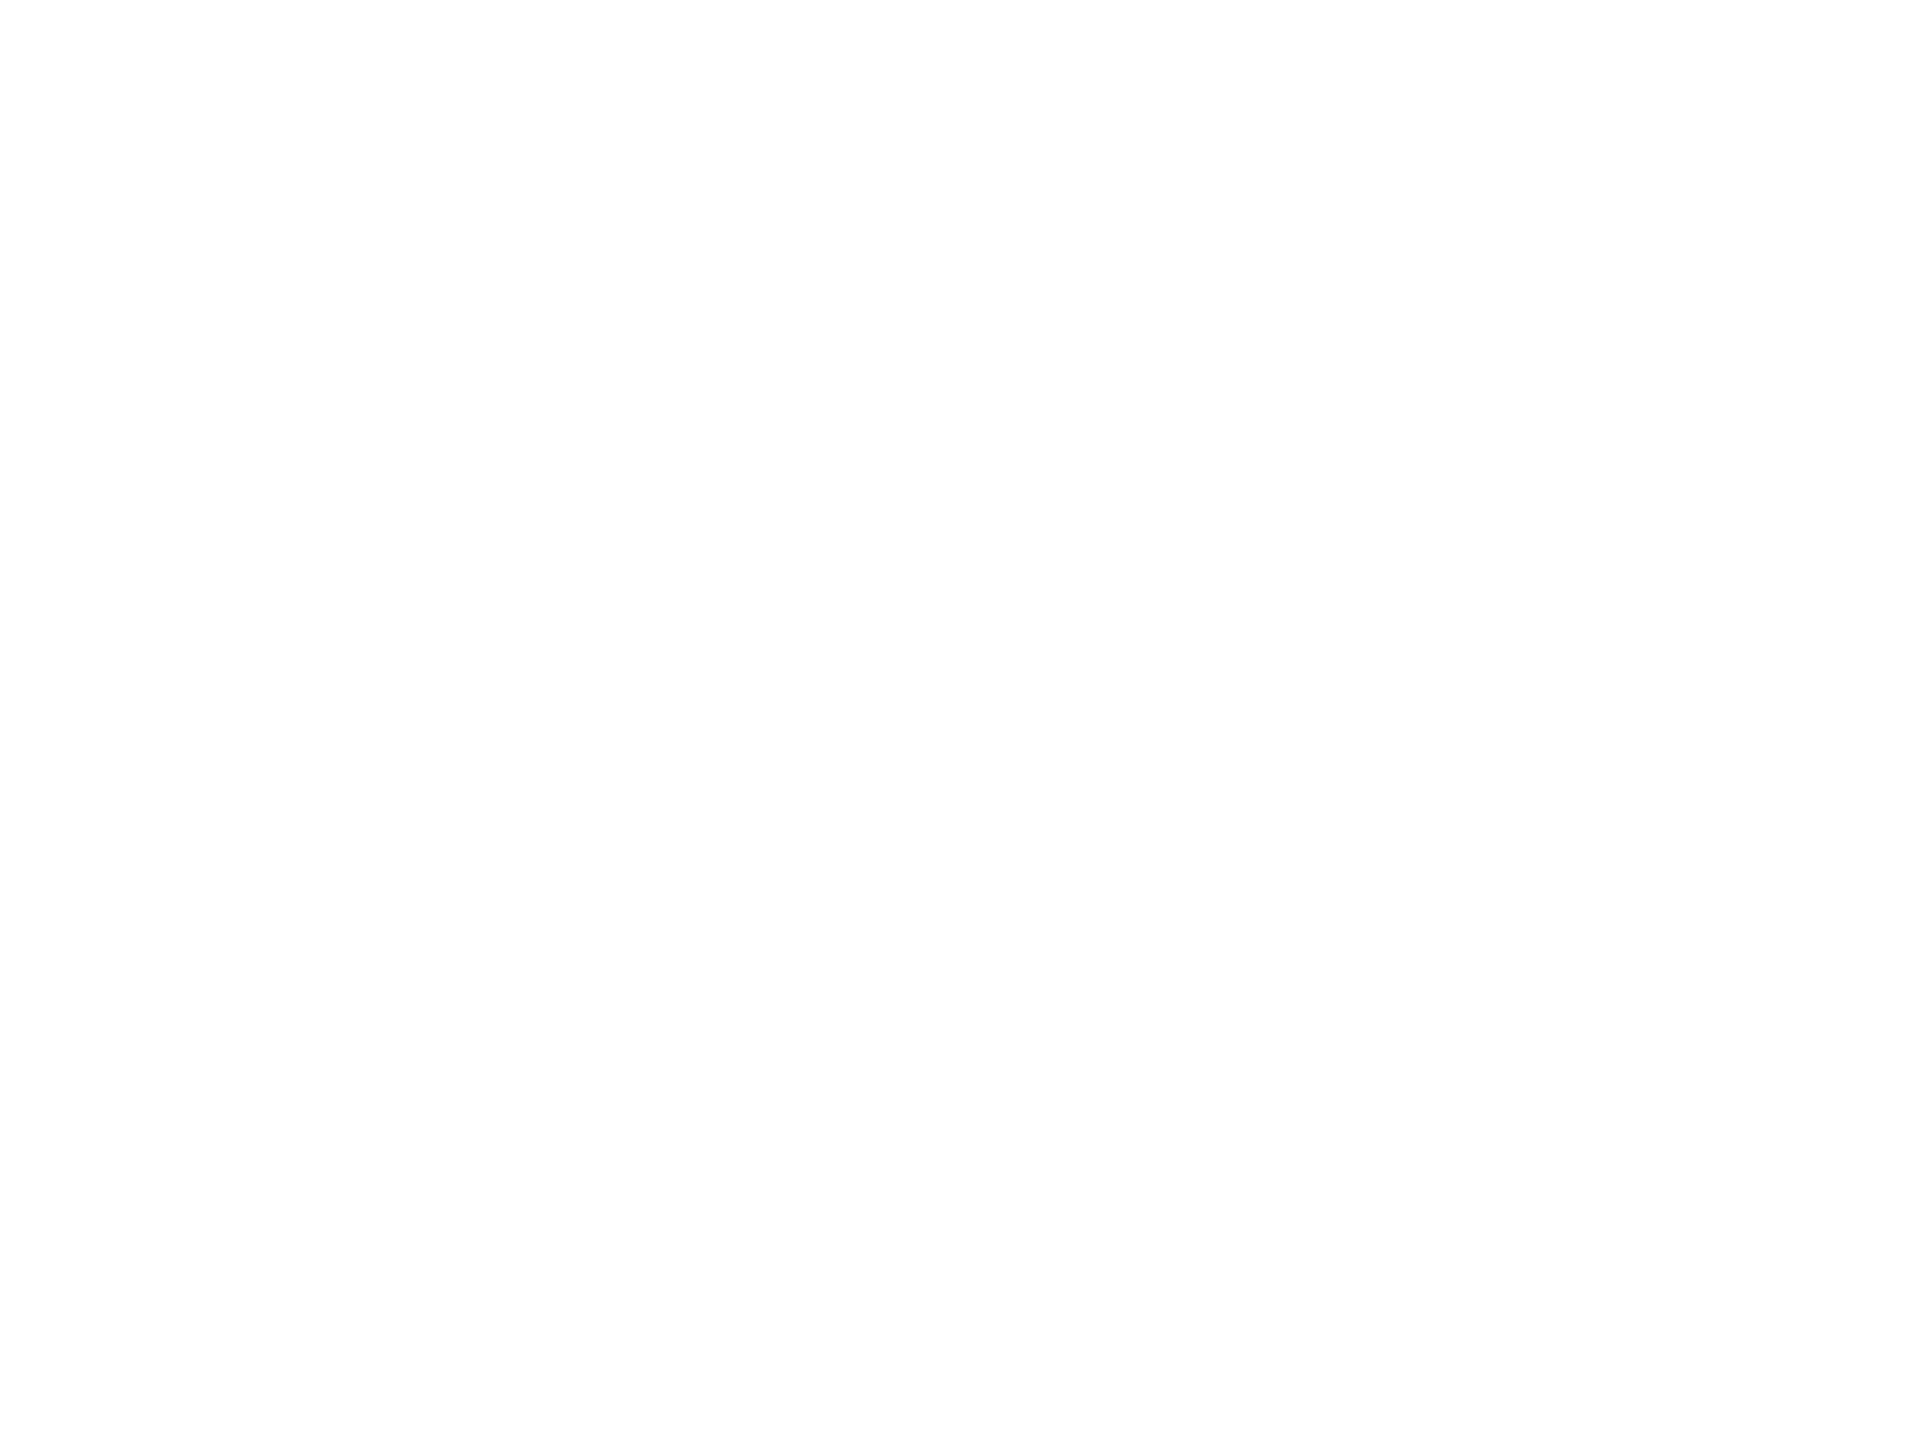

<Figure size 640x480 with 0 Axes>

In [38]:
#그래프 저장
plt.tight_layout()
plt.savefig("../outputs/figures/proof_stress_distribution.png", dpi=300)

from PIL import Image
from IPython.display import display

img = Image.open("../outputs/figures/proof_stress_distribution.png")
display(img)